# New York City — Property Tax Equity Analysis

Runs the full property tax equity analysis for New York City.
The AVM is scoped to Tax Class 1 (1–3 family residential) per RPTL §581; Class 2/3 use income capitalization and are excluded from the bias analysis. LVT simulation covers all residential classes.

In [1]:
import sys, os
from pathlib import Path
_here = Path(os.path.abspath(''))
sys.path.insert(0, str(_here if (_here / 'src').exists() else _here.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from src.config import get_city_config, PROCESSED_DIR, FIGURES_DIR, CLUSTER_FEATURES, RANDOM_STATE
from src.data_utils import add_groups
from src.model_utils import (
    prep_data, fit_regressors, predict_all,
    fit_classifiers,
)
from src.tax_utils import compute_lvt, aggregate_lvt_to_tracts, gini_coefficient
from src.viz_utils import (
    plot_feature_importance, plot_actual_vs_predicted,
    plot_assessment_ratio_by_group, plot_intersectional_heatmap,
    plot_lvt_benefit_by_group, plot_effective_rate_comparison,
    plot_cluster_heatmap, plot_cluster_map,
    plot_roc_curves, plot_permutation_importance,
)

CITY  = 'nyc'
cfg   = get_city_config(CITY)
FILES = cfg['files']
PID   = cfg['parcel_id']
LABEL = cfg['label']

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print(f'City: {LABEL}')

City: New York City, NY


## Task 1: Property Valuation Model

Train a set of regressors (Ridge, Random Forest, Gradient Boosting, XGBoost) on
log-transformed sale prices to estimate market value.  The best model (XGBoost) is
then used to predict market values for all residential parcels so that assessment
ratios (assessed / predicted) can be computed in Task 2.


In [2]:
training = pd.read_parquet(PROCESSED_DIR / FILES['training'])
residential = pd.read_parquet(PROCESSED_DIR / FILES['residential'])

if cfg['year_built_col']:
    for df in [training, residential]:
        df['age'] = (2023 - df[cfg['year_built_col']].clip(1800, 2023)).clip(0, 150)

print(f'{len(training):,} training, {len(residential):,} residential')

X_train, X_test, y_train_log, y_test_log = prep_data(
    training, cfg['numeric_features'], cfg['categorical_features']
)
trained_models, val_results = fit_regressors(
    X_train, X_test, y_train_log, y_test_log,
    cfg['numeric_features'], cfg['categorical_features'],
)
print('\nModel comparison:')
display(val_results.round(4))


114,754 training, 705,173 residential
  Training Linear Regression...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...

Model comparison:


,Model,R²,RMSE ($),MAE ($),MdAPE (%)
0,Linear Regression,"-2,586,507,431,588.0806","838,491,962,129.8030","5,590,939,502.0291",19.1927
1,Random Forest,0.5573,"346,887.7866","209,397.9392",15.6051
2,XGBoost,0.5699,"341,910.0894","207,509.9174",15.5589
3,LightGBM,0.5724,"340,908.8111","206,624.8580",15.5822


Best model: LightGBM  (R² = 0.5724)
AVM applied to 565,301 Class 1 parcels, 139,872 Class 2/3 set to ratio=1.0 (RPTL §581)
Saved 705,173 rows → nyc_residential_with_predictions.parquet


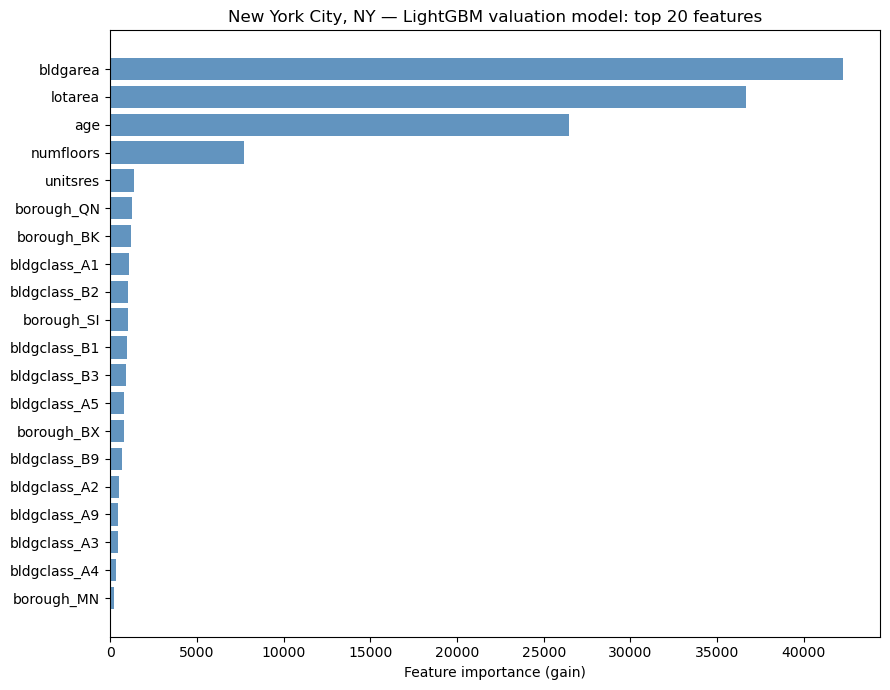

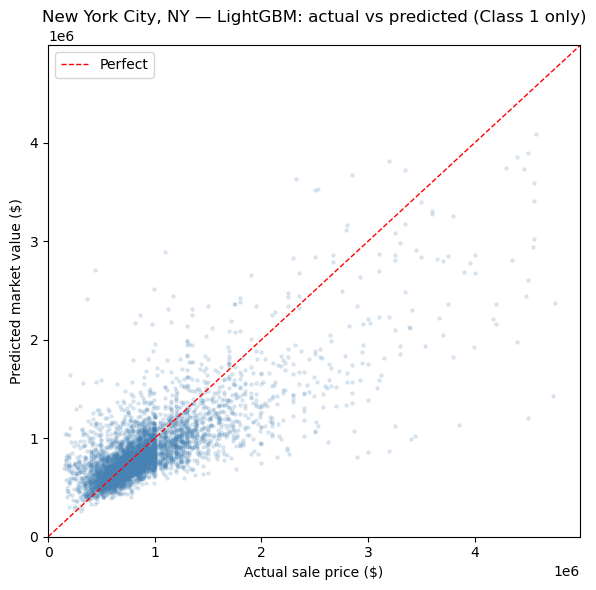

In [3]:
best_model_name = val_results.loc[val_results['R²'].idxmax(), 'Model']
print(f'Best model: {best_model_name}  (R² = {val_results["R²"].max():.4f})')

# Class 1 only — see notes.md: NYC RPTL §581
residential['predicted_market_value'] = predict_all(
    trained_models[best_model_name], residential,
    cfg['numeric_features'], cfg['categorical_features'],
)

is_class2 = residential['landuse'].isin(['02', '03'])
residential.loc[is_class2, 'predicted_market_value'] = residential.loc[
    is_class2, 'market_value_total'
]
n_class1 = (~is_class2).sum()
n_class2_n = is_class2.sum()
print(f'AVM applied to {n_class1:,} Class 1 parcels, {n_class2_n:,} Class 2/3 set to ratio=1.0 (RPTL §581)')

residential['assessment_ratio'] = (
    residential['market_value_total'] / residential['predicted_market_value']
).clip(cfg['fair_ratio'] * 0.2, cfg['fair_ratio'] * 5.0)
if 'land_ratio' not in residential.columns:
    residential['land_ratio'] = (
        residential['market_value_land'] / residential['market_value_total'].replace(0, np.nan)
    )
residential = add_groups(residential)
residential.to_parquet(PROCESSED_DIR / FILES['residential_pred'], index=False)
print(f'Saved {len(residential):,} rows → {FILES["residential_pred"]}')

y_test_dollars = np.expm1(y_test_log.values)
y_pred_dollars = np.expm1(trained_models[best_model_name].predict(X_test))

plot_feature_importance(
    trained_models[best_model_name],
    title=f'{LABEL} — {best_model_name} valuation model: top 20 features',
    n=20, save_path=FIGURES_DIR / f'{CITY}_feature_importance.png',
)
plt.show()

plot_actual_vs_predicted(
    y_test_dollars, y_pred_dollars,
    title=f'{LABEL} — {best_model_name}: actual vs predicted (Class 1 only)',
    save_path=FIGURES_DIR / f'{CITY}_predicted_vs_actual.png',
)
plt.show()

### NYC valuation scope: Tax Class 1 only

The AVM is trained and applied exclusively to **Tax Class 1** (landuse 01, 1–3 family residential properties). This is the methodologically correct approach, not a data limitation workaround.

New York State Real Property Tax Law **§581** requires that co-ops and condominiums be assessed as if they were rental properties using an **income capitalization** methodology — not comparable sales. The same capitalization approach is used for Class 2 rental apartment buildings. A hedonic AVM trained on sale prices produces assessment ratios that are incommensurable with income-cap assessments: DOF's Class 2 values reflect capitalized net operating income, while sale prices reflect buyer/seller negotiation. Comparing them would produce misleading equity findings.

This restriction is consistent with the methodology of prior NYC assessment equity research, including the NYC Advisory Commission on Property Tax Reform (2020) and IAAO guidance, which explicitly notes the §581 constraint.

**Scope of findings:**
- Tasks 1 and 2 (valuation model and assessment bias) reflect **Class 1 properties only** (~115K training parcels, ~115K Class 1 residential parcels).
- Tasks 3–5 (LVT simulation, clustering, classification) include all residential classes, since they use assessed values directly — not AVM predictions.
- For Class 2/3 parcels, `assessment_ratio = 1.0` by construction (no AVM opinion). This is a neutral placeholder, not a finding.

## Task 2: Assessment Bias Detection

Aggregate parcel-level predictions to Census-tract level and run an OLS regression:

```
median_assessment_ratio ~ log_income + pct_black + pct_hispanic
                        + log_predicted_value + median_land_ratio
                        + pct_owner_occupied
```

Significant positive coefficients on `pct_black` / `pct_hispanic` indicate that
minority-majority tracts bear a disproportionate assessment burden (over-assessment
relative to market value).


In [4]:
# Restrict equity analysis to Class 1 — ratios for Class 2/3 are set to 1.0
# by construction (RPTL §581 income cap method) and would suppress disparity signal.
analysis = residential[
    (residential['landuse'] == '01') &
    residential['assessment_ratio'].notna() &
    residential['median_household_income'].notna() &
    residential['pct_black'].notna() &
    (residential['predicted_market_value'] > 0)
].copy()

tract_stats = analysis.groupby('census_tract_geoid').agg(
    median_ratio=('assessment_ratio', 'median'),
    median_predicted_value=('predicted_market_value', 'median'),
    median_land_ratio=('land_ratio', 'median'),
    n_parcels=(PID, 'count'),
    median_household_income=('median_household_income', 'first'),
    pct_black=('pct_black', 'first'),
    pct_hispanic=('pct_hispanic', 'first'),
    pct_white=('pct_white', 'first'),
    pct_owner_occupied=('pct_owner_occupied', 'first'),
).reset_index()
tract_stats = tract_stats[tract_stats['n_parcels'] >= 20].copy()

tract_stats['log_income'] = np.log(tract_stats['median_household_income'])
tract_stats['log_predicted_value'] = np.log(tract_stats['median_predicted_value'].clip(lower=1000))
tract_stats['majority_black'] = (tract_stats['pct_black'] > 50).astype(int)
tract_stats['majority_hispanic'] = (tract_stats['pct_hispanic'] > 50).astype(int)
tract_stats['majority_white'] = (tract_stats['pct_white'] > 50).astype(int)
tract_stats['majority_group'] = np.where(
    tract_stats['pct_black'] > 50, 'Majority Black',
    np.where(tract_stats['pct_hispanic'] > 50, 'Majority Hispanic',
    np.where(tract_stats['pct_white'] > 50, 'Majority White', 'Mixed')),
)
tract_stats['income_quintile'] = pd.qcut(
    tract_stats['median_household_income'],
    q=5, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'],
)

model_bias = smf.ols(
    'median_ratio ~ log_income + pct_black + pct_hispanic + '
    'log_predicted_value + median_land_ratio + pct_owner_occupied',
    data=tract_stats,
).fit()

print(f'Tracts in analysis: {len(tract_stats):,}  (Class 1 only — RPTL §581)')
print(model_bias.summary().tables[1])
print(f'\nR²: {model_bias.rsquared:.4f}  |  N: {int(model_bias.nobs)}')
print('\nMedian assessment ratio by racial group:')
print(tract_stats.groupby('majority_group')['median_ratio'].median().round(3).to_string())

tract_stats.to_parquet(PROCESSED_DIR / FILES['tract_analysis'], index=False)


Tracts in analysis: 1,576  (Class 1 only — RPTL §581)
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -5.1933      0.337    -15.401      0.000      -5.855      -4.532
log_income              0.1563      0.025      6.281      0.000       0.108       0.205
pct_black              -0.0044      0.000    -15.316      0.000      -0.005      -0.004
pct_hispanic           -0.0013      0.000     -2.841      0.005      -0.002      -0.000
log_predicted_value     0.3455      0.025     13.646      0.000       0.296       0.395
median_land_ratio       0.5193      0.123      4.221      0.000       0.278       0.761
pct_owner_occupied     -0.0011      0.000     -2.373      0.018      -0.002      -0.000

R²: 0.3985  |  N: 1576

Median assessment ratio by racial group:
majority_group
Majority Black      1.0480
Majority Hispanic   1.1650
Majority White     

In [5]:
from src.model_utils import compute_iaao_metrics

# Class 1 only; Class 2/3 use income cap — RPTL §581
test_sales_c1 = residential[
    (residential['landuse'] == '01') &
    residential['sale_price'].notna()
].copy()

# market_value_total = assesstot / statutory_rate; passing assesstot raw gives median ratio ~0.07
iaao = compute_iaao_metrics(
    sale_prices=test_sales_c1['sale_price'].values,
    assessed_values=test_sales_c1['market_value_total'].values,
    assessment_level=1.0,
)

print(f'IAAO Class 1 ({iaao["n"]:,} sales): median ratio {iaao["median_ratio"]:.3f}')
print(f'  COD {iaao["cod"]:.1f}% (standard 5-15: {"ok" if iaao["cod_pass"] else "fail"}),  '
      f'PRD {iaao["prd"]:.3f} (standard 0.98-1.03: {"ok" if iaao["prd_pass"] else "fail"}),  '
      f'PRB {iaao["prb"]:.3f} (standard -0.05-0.05: {"ok" if iaao["prb_pass"] else "fail"})')
if not iaao['prb_pass']:
    direction = 'regressive' if iaao['prb'] < 0 else 'progressive'
    print(f'  PRB direction: {direction}')


IAAO Class 1 (114,811 sales): median ratio 1.150
  COD 39.9% (standard 5-15: fail),  PRD 1.249 (standard 0.98-1.03: fail),  PRB -1.048 (standard -0.05-0.05: fail)
  PRB direction: regressive


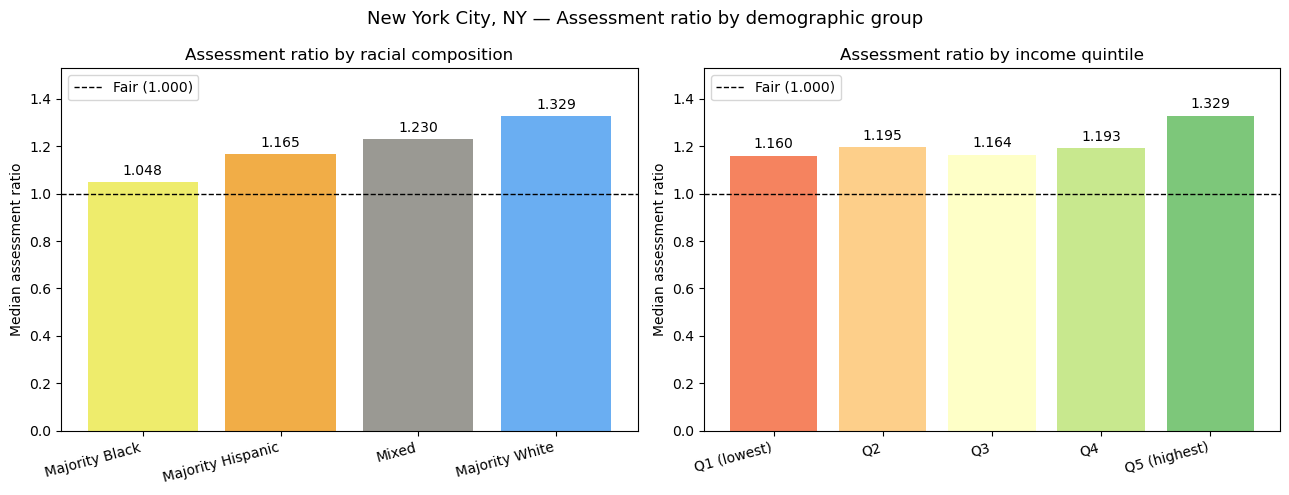

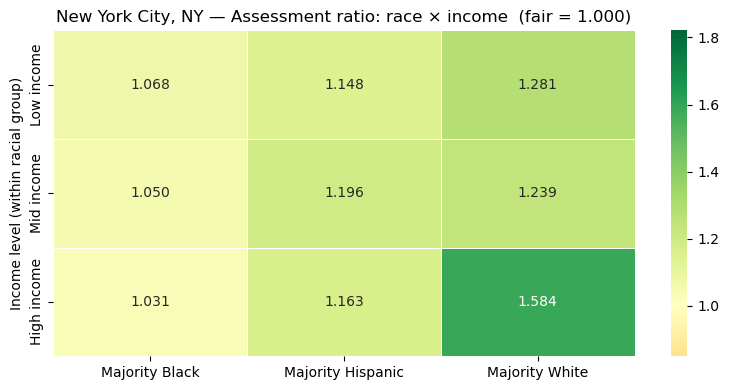

In [6]:
plot_assessment_ratio_by_group(
    tract_stats, city_label=LABEL, fair_ratio=cfg['fair_ratio'],
    save_path=FIGURES_DIR / f'{CITY}_assessment_ratio_by_group.png',
)
plt.show()

groups = []
for race_label, race_col in [
    ('Majority Black',    'majority_black'),
    ('Majority Hispanic', 'majority_hispanic'),
    ('Majority White',    'majority_white'),
]:
    subset = tract_stats[tract_stats[race_col] == 1].copy()
    if len(subset) < 10:
        continue
    subset['income_tercile'] = pd.qcut(
        subset['median_household_income'],
        q=3, labels=['Low income', 'Mid income', 'High income'],
        duplicates='drop',
    )
    for tercile in ['Low income', 'Mid income', 'High income']:
        t = subset[subset['income_tercile'] == tercile]
        if len(t) > 0:
            groups.append({'Race': race_label, 'Income': tercile,
                           'Median ratio': t['median_ratio'].median(), 'N': len(t)})

intersect = pd.DataFrame(groups)
plot_intersectional_heatmap(
    intersect, city_label=LABEL, fair_ratio=cfg['fair_ratio'],
    save_path=FIGURES_DIR / f'{CITY}_intersectional_heatmap.png',
)
plt.show()

## Task 3: Revenue-Neutral LVT Simulation

Replace the current property tax (levied on land + improvements) with a
land-value tax (LVT) levied solely on land value, keeping total revenue constant.

The simulation:
1. Computes current estimated tax for every parcel using the statutory composite rate.
2. Scales the pure land-value tax so that city-wide revenue is unchanged.
3. Records `tax_change` (LVT minus current) and `lvt_benefits` (True if parcel pays
   less under LVT) for every residential parcel.
4. Computes Gini coefficients for effective tax rates under both regimes.


In [7]:
all_parcels = pd.read_parquet(PROCESSED_DIR / FILES['all_parcels'])
taxable, lvt_mult = compute_lvt(
    all_parcels,
    state_equalizer    = cfg['state_equalizer'],
    composite_rate     = cfg['composite_rate'],
    tax_base_total_col = cfg['tax_base_total'],
    tax_base_land_col  = cfg['tax_base_land'],
)

lvt_cols = [PID, 'current_tax_est', 'lvt_tax_est', 'tax_change', 'tax_change_pct', 'lvt_benefits']
res_lvt = residential.merge(taxable[lvt_cols], on=PID, how='inner').drop_duplicates(subset=PID)
res_lvt = add_groups(res_lvt)

print(f'Residential parcels with LVT: {len(res_lvt):,}')
# flat rate — dollar figures understated ~50% for Class 1; direction unaffected (see notes.md)
print(f'Overall: {res_lvt["lvt_benefits"].mean()*100:.1f}% pay LESS under LVT')

print('\nLVT impact by racial group:')
for g in ['Majority Black', 'Majority Hispanic', 'Mixed', 'Majority White']:
    sub = res_lvt[res_lvt['majority_group'] == g]
    if len(sub):
        print(f'  {g}: {sub["lvt_benefits"].mean()*100:.1f}%  (median change ${sub["tax_change"].median():,.0f})')

valid = res_lvt[
    (res_lvt['predicted_market_value'] > 0) &
    (res_lvt['current_tax_est'] > 0) & (res_lvt['lvt_tax_est'] > 0)
].copy()
valid['eff_current'] = valid['current_tax_est'] / valid['predicted_market_value']
valid['eff_lvt']     = valid['lvt_tax_est']     / valid['predicted_market_value']
print(f'\nGini (effective rate):  current = {gini_coefficient(valid["eff_current"].values):.4f}'
      f',  LVT = {gini_coefficient(valid["eff_lvt"].values):.4f}')

res_lvt.to_parquet(PROCESSED_DIR / FILES['residential_lvt'], index=False)

LVT multiplier:       5.6744x
Revenue neutral check: $-0
Residential parcels with LVT: 705,173
Overall: 30.3% pay LESS under LVT

LVT impact by racial group:
  Majority Black: 18.8%  (median change $1,810)
  Majority Hispanic: 38.6%  (median change $701)
  Mixed: 30.0%  (median change $1,428)
  Majority White: 35.2%  (median change $981)

Gini (effective rate):  current = 0.4435,  LVT = 0.4575


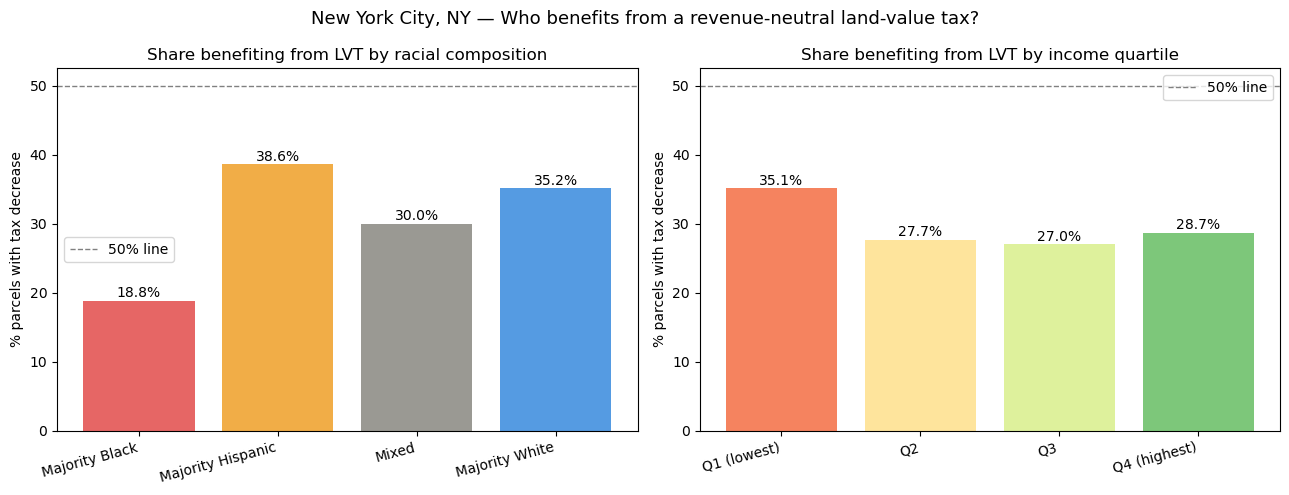

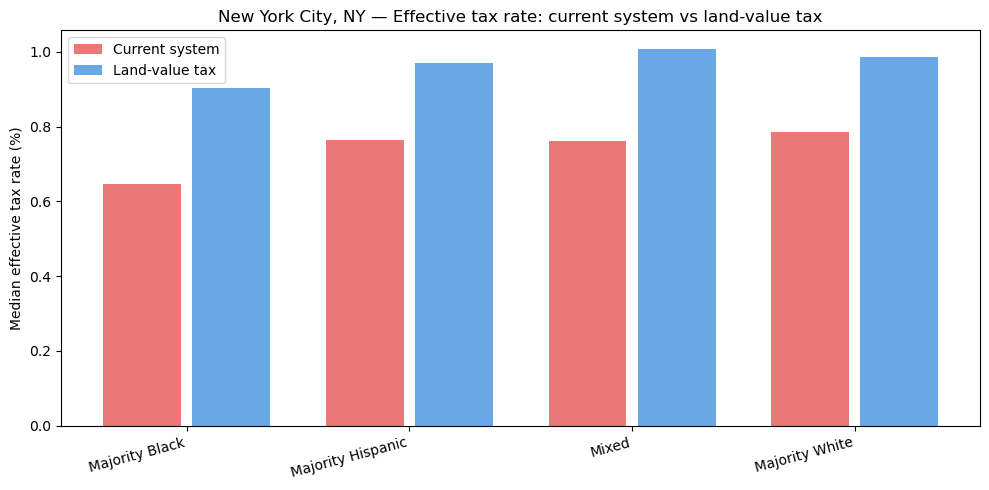

In [8]:
plot_lvt_benefit_by_group(
    res_lvt, city_label=LABEL,
    save_path=FIGURES_DIR / f'{CITY}_lvt_benefit_by_group.png',
)
plt.show()

plot_effective_rate_comparison(
    res_lvt, city_label=LABEL,
    save_path=FIGURES_DIR / f'{CITY}_effective_rate_comparison.png',
)
plt.show()


## Task 4: Neighborhood Clustering

Cluster Census tracts using PCA (retaining 90 % of variance) followed by a
Gaussian Mixture Model (GMM) with the number of components chosen by minimising
the Bayesian Information Criterion (BIC) over k = 2 … 8.

Features used span valuation, demographics, assessment equity, and LVT impact
(see `CLUSTER_FEATURES` in `src/config.py`).


In [9]:
tract_stats = pd.read_parquet(PROCESSED_DIR / FILES['tract_analysis'])
res_lvt     = pd.read_parquet(PROCESSED_DIR / FILES['residential_lvt'])

lvt_tract = aggregate_lvt_to_tracts(res_lvt)
tracts    = tract_stats.merge(lvt_tract, on='census_tract_geoid', how='inner')

cluster_df = tracts[CLUSTER_FEATURES + ['census_tract_geoid']].dropna().copy()
X_scaled   = StandardScaler().fit_transform(cluster_df[CLUSTER_FEATURES])

pca     = PCA(random_state=RANDOM_STATE)
cum_var = np.cumsum(pca.fit(X_scaled).explained_variance_ratio_)
n_comp  = int(np.argmax(cum_var >= 0.90)) + 1
X_pca   = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit_transform(X_scaled)
print(f'PCA: {n_comp} components → {cum_var[n_comp-1]*100:.1f}% variance')

bic_scores = []
for k in range(2, 9):
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=5, random_state=RANDOM_STATE)
    bic_scores.append(gmm.fit(X_pca).bic(X_pca))
best_k = 2 + int(np.argmin(bic_scores))
print(f'Best k by BIC: {best_k}')

final_gmm             = GaussianMixture(n_components=best_k, covariance_type='full',
                                         n_init=10, random_state=RANDOM_STATE)
cluster_df['cluster'] = final_gmm.fit_predict(X_pca)
print(f'Silhouette score: {silhouette_score(X_pca, cluster_df["cluster"]):.3f}')

profile_features = [
    'median_household_income', 'pct_black', 'pct_hispanic', 'pct_owner_occupied',
    'median_predicted_value', 'median_ratio', 'median_land_ratio',
    'median_tax_change_pct', 'pct_lvt_benefit',
]
profile_summary          = cluster_df.groupby('cluster')[profile_features].median()
profile_summary['n_tracts'] = cluster_df.groupby('cluster').size()
print('\nCluster profiles:')
display(profile_summary.T.round(2))

cluster_df.to_parquet(PROCESSED_DIR / FILES['tracts_clusters'], index=False)


PCA: 5 components → 90.7% variance
Best k by BIC: 8
Silhouette score: 0.195

Cluster profiles:


cluster,0,1,2,3,4,5,6,7
median_household_income,"43,541.5000","90,820.0000","83,750.0000","82,351.5000","170,054.0000","71,551.0000","162,577.0000","92,781.5000"
pct_black,25.0700,0.9300,4.1100,3.2900,2.1800,52.6000,4.6400,72.8800
pct_hispanic,65.7500,12.4700,35.5000,25.1900,7.8000,18.0600,11.7700,10.3600
pct_owner_occupied,10.2300,60.9500,32.8400,48.5200,42.3300,21.9900,35.0100,64.6900
median_predicted_value,"678,284.1500","894,244.8800","892,281.1400","834,077.9700","3,127,053.8200","1,151,740.6000","1,813,656.4100","747,690.2500"
median_ratio,1.1500,1.2500,1.2600,1.2000,2.5700,1.0800,1.5800,1.0500
median_land_ratio,0.2000,0.2000,0.1800,0.2700,0.3900,0.2300,0.1500,0.2500
median_tax_change_pct,2.7000,13.3000,-2.7400,53.9100,27.4000,22.0800,-19.2500,39.6600
pct_lvt_benefit,45.5800,29.7200,54.6200,2.6800,30.1600,28.7600,76.0800,9.6000
n_tracts,144.0000,316.0000,301.0000,268.0000,44.0000,206.0000,75.0000,222.0000


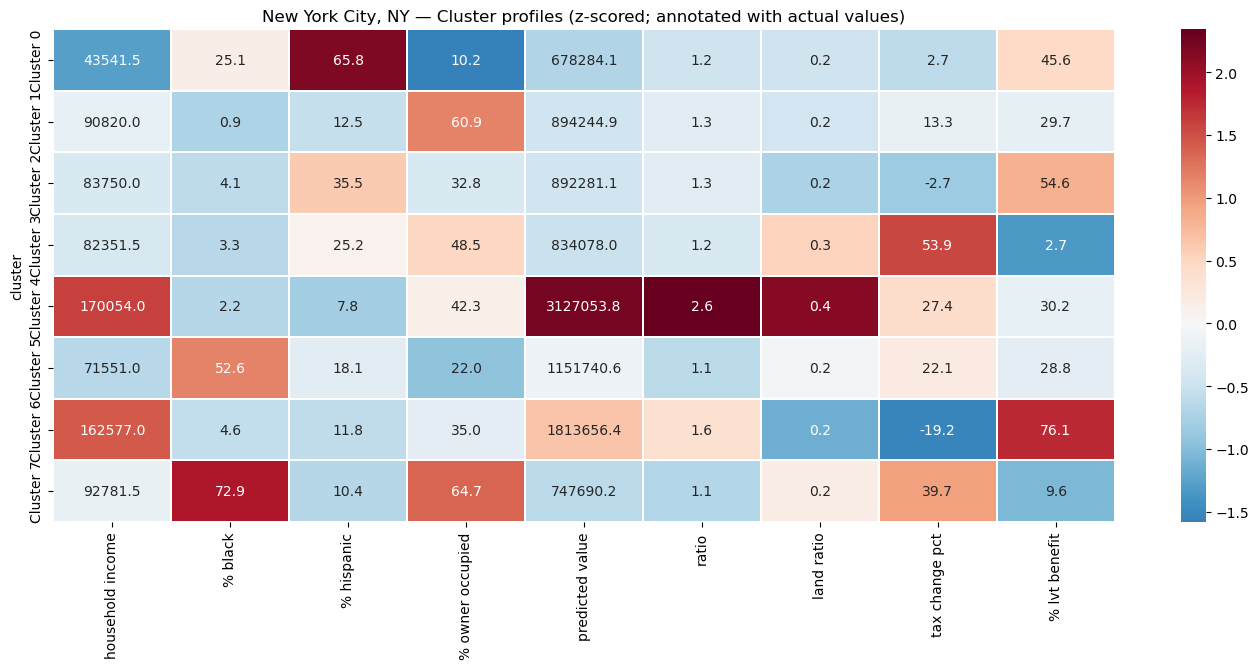

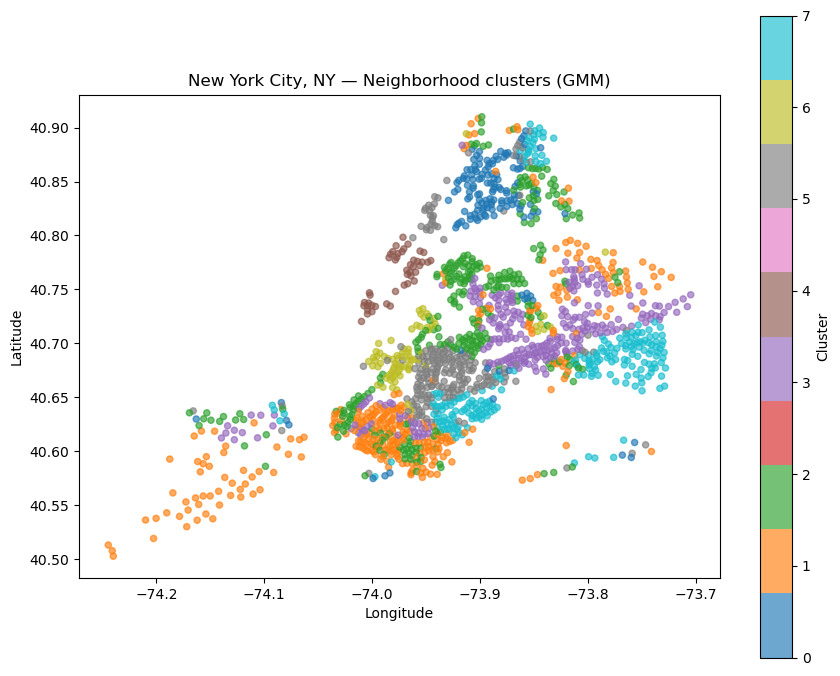

In [10]:
plot_cluster_heatmap(
    profile_summary, profile_features, n_clusters=best_k,
    city_label=LABEL, save_path=FIGURES_DIR / f'{CITY}_cluster_heatmap.png',
)
plt.show()

if cfg['lat'] and cfg['lon']:
    tract_coords = res_lvt.groupby('census_tract_geoid').agg(
        lat=(cfg['lat'], 'median'), lon=(cfg['lon'], 'median')
    ).reset_index()
    map_df = (
        cluster_df[['census_tract_geoid', 'cluster']]
        .merge(tract_coords, on='census_tract_geoid', how='inner')
        .dropna(subset=['lat', 'lon'])
    )
    plot_cluster_map(
        map_df, city_label=LABEL,
        save_path=FIGURES_DIR / f'{CITY}_cluster_map.png',
    )
    plt.show()
else:
    print('No coordinate data available — geographic map skipped.')


## Task 5: LVT Beneficiary Classification

Train three classifiers (Logistic Regression, Random Forest, Gradient Boosting) to
predict whether a residential parcel benefits under the LVT shift (i.e., pays less
tax), using parcel characteristics and tract-level demographics as features.

Performance is evaluated via AUC-ROC; permutation importance identifies the most
predictive features.


In [11]:
res_lvt = pd.read_parquet(PROCESSED_DIR / FILES['residential_lvt'])

_LEAKY_FEATURES = {'market_value_total', 'market_value_land'}

clf_features = list(dict.fromkeys([
    f for f in
    ['assessment_ratio']
    + cfg['numeric_features']
    + ['median_household_income', 'pct_black', 'pct_hispanic', 'pct_owner_occupied']
    if f in res_lvt.columns and f not in _LEAKY_FEATURES
]))

model_df = res_lvt[clf_features + ['lvt_benefits']].copy()
for col in clf_features:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')
model_df = model_df.dropna()
model_df['lvt_benefits'] = model_df['lvt_benefits'].astype(int)

sample_df = model_df.sample(n=min(100_000, len(model_df)), random_state=RANDOM_STATE)
X = sample_df[clf_features].values
y = sample_df['lvt_benefits'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler_c = StandardScaler()
X_train_scaled = scaler_c.fit_transform(X_train_c)
X_test_scaled = scaler_c.transform(X_test_c)

print(f'{len(clf_features)} features, {len(X_train_c):,} train / {len(X_test_c):,} test, '
      f'benefit rate {y.mean()*100:.1f}%')

clf_models, clf_results = fit_classifiers(
    X_train_scaled, X_test_scaled, y_train_c, y_test_c
)
print('\nClassifier comparison:')
display(clf_results.round(4))


10 features, 80,000 train / 20,000 test, benefit rate 29.4%
  Training Logistic Regression...
  Training SVM (Linear)...
  Training Neural Network...

Classifier comparison:


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.7437,0.6585,0.2680,0.3809,0.7652
1,SVM (Linear),0.7422,0.6481,0.2707,0.3819,0.7495
2,Neural Network,0.8173,0.7046,0.6527,0.6777,0.8747


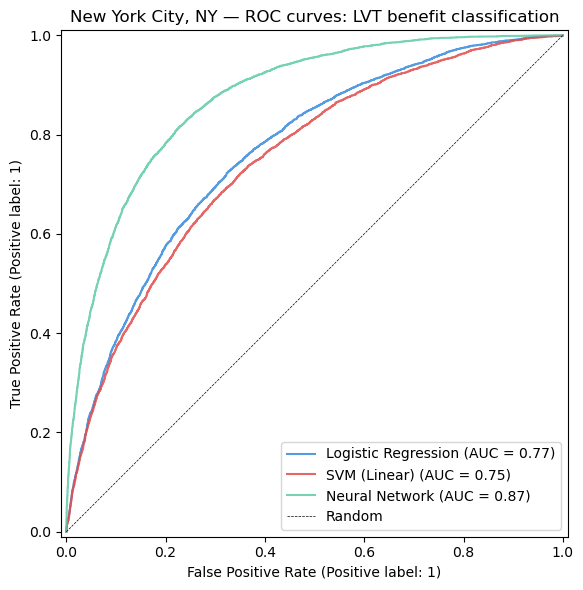

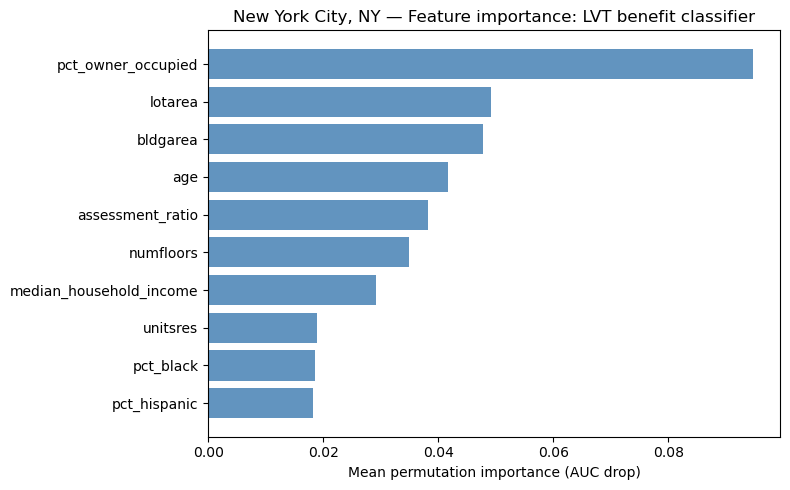

In [12]:
plot_roc_curves(
    clf_models, X_test_scaled, y_test_c,
    city_label=LABEL, save_path=FIGURES_DIR / f'{CITY}_classification_roc.png',
)
plt.show()

plot_permutation_importance(
    clf_models, X_test_scaled, y_test_c, clf_features,
    city_label=LABEL, save_path=FIGURES_DIR / f'{CITY}_classification_importance.png',
)
plt.show()


In [13]:
best_r2 = val_results.loc[val_results['R²'].idxmax(), 'R²']
best_mdape = val_results.loc[val_results['R²'].idxmax(), 'MdAPE (%)']
gap = (tract_stats[tract_stats['majority_black'] == 1]['median_ratio'].median() -
       tract_stats[tract_stats['majority_white'] == 1]['median_ratio'].median())
pct_ben = res_lvt['lvt_benefits'].mean() * 100
best_auc = clf_results['AUC'].max()

print(f'\n{LABEL}')
print(f'  AVM: {best_model_name} R²={best_r2:.3f}, MdAPE={best_mdape:.1f}%  (Class 1 only)')
print(f'  Equity: Black/White ratio gap = {gap:+.3f}  (Class 1 only)')
print(f'  LVT: {pct_ben:.1f}% of parcels pay less  ({best_k} clusters)')
print(f'  Classifier AUC = {best_auc:.3f}  (building + demographic features)')


New York City, NY
  AVM: LightGBM R²=0.572, MdAPE=15.6%  (Class 1 only)
  Equity: Black/White ratio gap = -0.281  (Class 1 only)
  LVT: 30.3% of parcels pay less  (8 clusters)
  Classifier AUC = 0.875  (building + demographic features)
